点碰撞检测:
  点(0, 0): 碰撞!
  点(2, 0): 安全
  点(-1, 1): 安全

圆形障碍物碰撞检测:
  障碍物1在(1.5, 0.8): 碰撞!
  障碍物2在(-2, -1): 碰撞!
  障碍物3在(0, 2): 安全

碰撞圆的世界坐标:
  圆1: 中心(-1.15, -0.67), 半径=1.00
  圆2: 中心(0.00, 0.00), 半径=1.00
  圆3: 中心(1.15, 0.67), 半径=1.00


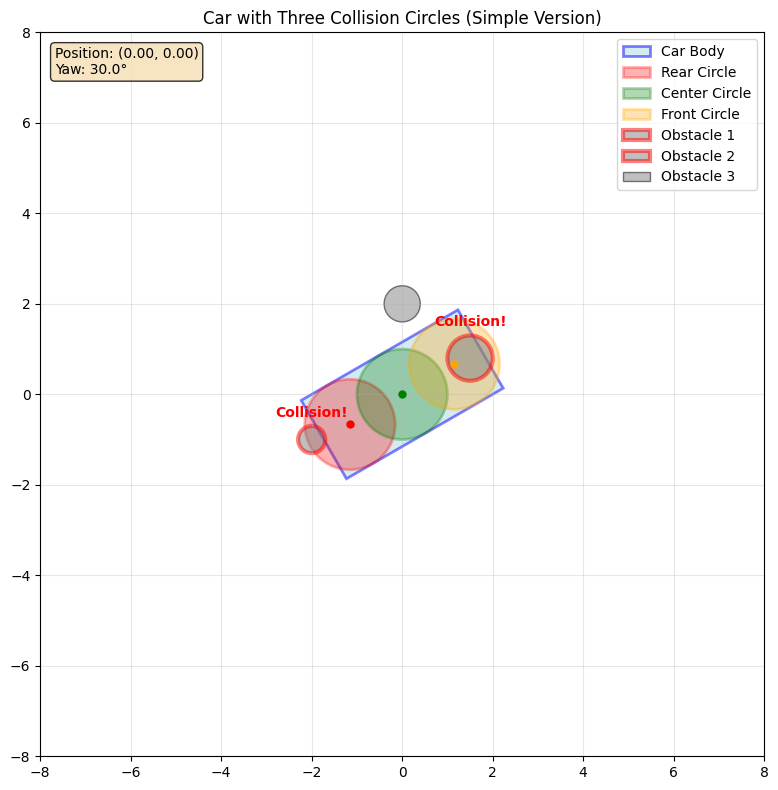


演示不同位姿的碰撞检测:
  位姿(0, 0, 0°): 碰撞
  位姿(2, 1, 45°): 碰撞
  位姿(-1, -2, 90°): 碰撞


In [4]:
import numpy as np
import matplotlib.pyplot as plt

class SimpleCarThreeCircles:
    """简化版：使用三个碰撞圆拟合车体"""
    
    def __init__(self, length=4.0, width=2.0):
        self.length = length
        self.width = width
        
        # 世界坐标：车体中心位置和朝向
        self.x = 0.0
        self.y = 0.0
        self.yaw = 0.0  # 弧度
        
        # 三个圆的局部坐标（相对车体中心）
        self.circles_local = [
            {'x': -length/3, 'y': 0, 'r': width/2 * 1},      # 后圆
            {'x': 0, 'y': 0, 'r': width/2 * 1},             # 中心圆
            {'x': length/3, 'y': 0, 'r': width/2 * 1}       # 前圆
        ]
    
    def set_pose(self, x, y, yaw):
        """设置车体在世界坐标系中的位姿"""
        self.x = x
        self.y = y
        self.yaw = yaw
    
    def get_circles_world(self):
        """获取三个圆在世界坐标系中的位置和半径"""
        cos_yaw = np.cos(self.yaw)
        sin_yaw = np.sin(self.yaw)
        
        circles_world = []
        for circle in self.circles_local:
            # 局部坐标转世界坐标
            local_x, local_y = circle['x'], circle['y']
            world_x = self.x + local_x * cos_yaw - local_y * sin_yaw
            world_y = self.y + local_x * sin_yaw + local_y * cos_yaw
            
            circles_world.append({
                'x': world_x,
                'y': world_y,
                'r': circle['r']
            })
        
        return circles_world
    
    def check_collision_point(self, point_x, point_y):
        """检测点是否与车体碰撞"""
        circles = self.get_circles_world()
        
        for circle in circles:
            distance = np.sqrt((point_x - circle['x'])**2 + 
                              (point_y - circle['y'])**2)
            if distance <= circle['r']:
                return True
        return False
    
    def check_collision_circle(self, obs_x, obs_y, obs_r):
        """检测与圆形障碍物的碰撞"""
        circles = self.get_circles_world()
        
        for circle in circles:
            distance = np.sqrt((obs_x - circle['x'])**2 + 
                              (obs_y - circle['y'])**2)
            if distance <= (circle['r'] + obs_r):
                return True
        return False
    
    def get_car_corners_world(self):
        """获取车体四个角的世界坐标"""
        half_l = self.length / 2
        half_w = self.width / 2
        
        # 局部坐标的四个角
        corners_local = [
            [-half_l, -half_w],  # 左后
            [-half_l, half_w],   # 左前
            [half_l, half_w],    # 右前
            [half_l, -half_w]    # 右后
        ]
        
        cos_yaw = np.cos(self.yaw)
        sin_yaw = np.sin(self.yaw)
        
        corners_world = []
        for lx, ly in corners_local:
            wx = self.x + lx * cos_yaw - ly * sin_yaw
            wy = self.y + lx * sin_yaw + ly * cos_yaw
            corners_world.append([wx, wy])
        
        return corners_world


def visualize_car(car, obstacles=None):
    """可视化车体和碰撞圆"""
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    
    # 获取车体角点
    corners = car.get_car_corners_world()
    
    # 绘制车体
    from matplotlib.patches import Polygon
    car_poly = Polygon(corners, closed=True, 
                      edgecolor='blue', facecolor='lightblue', 
                      alpha=0.5, linewidth=2, label='Car Body')
    ax.add_patch(car_poly)
    
    # 绘制三个碰撞圆
    circles = car.get_circles_world()
    colors = ['red', 'green', 'orange']
    labels = ['Rear Circle', 'Center Circle', 'Front Circle']
    
    for i, circle in enumerate(circles):
        from matplotlib.patches import Circle as MplCircle
        circ = MplCircle((circle['x'], circle['y']), circle['r'],
                        edgecolor=colors[i], facecolor=colors[i], 
                        alpha=0.3, linewidth=2, label=labels[i])
        ax.add_patch(circ)
        
        # 标记圆心
        ax.plot(circle['x'], circle['y'], 'o', color=colors[i], markersize=5)
    
    # 绘制障碍物（如果有）
    if obstacles:
        for i, (x, y, r) in enumerate(obstacles):
            obs_circle = MplCircle((x, y), r, 
                                  edgecolor='black', facecolor='gray', 
                                  alpha=0.5, label=f'Obstacle {i+1}')
            ax.add_patch(obs_circle)
            
            # 检测碰撞
            if car.check_collision_circle(x, y, r):
                obs_circle.set_edgecolor('red')
                obs_circle.set_linewidth(3)
                ax.text(x, y + r + 0.2, 'Collision!', 
                       color='red', ha='center', fontweight='bold')
    
    # 设置坐标轴
    margin = max(car.length, car.width) * 2
    ax.set_xlim(car.x - margin, car.x + margin)
    ax.set_ylim(car.y - margin, car.y + margin)
    
    # 添加图例
    ax.legend(loc='upper right')
    
    # 显示车体信息
    info = f'Position: ({car.x:.2f}, {car.y:.2f})\n'
    info += f'Yaw: {np.degrees(car.yaw):.1f}°'
    ax.text(0.02, 0.98, info, transform=ax.transAxes,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    ax.set_title('Car with Three Collision Circles (Simple Version)')
    plt.tight_layout()
    plt.show()


# 示例使用
if __name__ == "__main__":
    # 1. 创建车体
    car = SimpleCarThreeCircles(length=4.0, width=2.0)
    
    # 2. 设置车体位姿（世界坐标）
    car.set_pose(x=0, y=0, yaw=np.radians(30))  # 30度朝向
    
    # 3. 创建障碍物 (x, y, radius)
    obstacles = [
        (1.5, 0.8, 0.5),    # 可能碰撞的障碍物
        (-2, -1, 0.3),      # 不会碰撞的障碍物
        (0, 2, 0.4),        # 另一个障碍物
    ]
    
    # 4. 检测点碰撞
    test_points = [(0, 0), (2, 0), (-1, 1)]
    print("点碰撞检测:")
    for px, py in test_points:
        if car.check_collision_point(px, py):
            print(f"  点({px}, {py}): 碰撞!")
        else:
            print(f"  点({px}, {py}): 安全")
    
    # 5. 检测圆形障碍物碰撞
    print("\n圆形障碍物碰撞检测:")
    for i, (ox, oy, orad) in enumerate(obstacles):
        if car.check_collision_circle(ox, oy, orad):
            print(f"  障碍物{i+1}在({ox}, {oy}): 碰撞!")
        else:
            print(f"  障碍物{i+1}在({ox}, {oy}): 安全")
    
    # 6. 获取世界坐标中的碰撞圆信息
    print("\n碰撞圆的世界坐标:")
    circles_world = car.get_circles_world()
    for i, circle in enumerate(circles_world):
        print(f"  圆{i+1}: 中心({circle['x']:.2f}, {circle['y']:.2f}), "
              f"半径={circle['r']:.2f}")
    
    # 7. 可视化
    visualize_car(car, obstacles)
    
    # 8. 演示运动
    print("\n演示不同位姿的碰撞检测:")
    test_poses = [
        (0, 0, 0),      # 0度
        (2, 1, 45),     # 45度
        (-1, -2, 90),   # 90度
    ]
    
    for tx, ty, tyaw in test_poses:
        car.set_pose(tx, ty, np.radians(tyaw))
        colliding = False
        
        for ox, oy, orad in obstacles:
            if car.check_collision_circle(ox, oy, orad):
                colliding = True
                break
        
        status = "碰撞" if colliding else "安全"
        print(f"  位姿({tx}, {ty}, {tyaw}°): {status}")